# H₂+H₂ interaction energies: `cross_product` vs joint (std) KQD

Extends [`krylov_cross_product_protocols.ipynb`](krylov_cross_product_protocols.ipynb) §8 / §8a / §8b for **real-chemistry** H₂⋯H₂ (Parity-mapped) at $R=1.1$ Å and $R=1000$ Å.

**Methods**
- `cross_product` ($N^2$ states): $|\Phi^{\mathrm{cp}}_{kl}\rangle = e^{-i(k H_A+l H_B)\Delta t}|\psi_0\rangle$
- `joint` / std ($N$ states): $|\Phi^{\mathrm{j}}_{k}\rangle = e^{-i H k\Delta t}|\psi_0\rangle$

**Four interaction-energy comparisons** (same Krylov order $N$):

| ID | Formula | Role |
|---|---|---|
| **C1** | $E_{\mathrm{cp}}(R{=}1.1) - 2E_{\mathrm{joint}}(\mathrm{H_2};N)$ | cross_product vs monomers |
| **C2** | $E_{\mathrm{cp}}(R{=}1.1) - E_{\mathrm{cp}}(R{=}1000)$ | cross_product R-diff |
| **C3** | $E_{\mathrm{joint}}(R{=}1.1) - 2E_{\mathrm{joint}}(\mathrm{H_2};N)$ | joint vs monomers |
| **C4** | $E_{\mathrm{joint}}(R{=}1.1) - E_{\mathrm{joint}}(R{=}1000)$ | joint R-diff |

**SC identity test**
- Size-consistent method $\Rightarrow$ C1 $=$ C2 (`gap_cp` $= |$C1$-$C2$|$ $\to 0$).
- Prior finding: joint KQD is **not** size-consistent at fixed $N$ $\Rightarrow$ expect C3 $\neq$ C4 (`gap_joint` $> 0$).

Monomer refs use joint QKD at the **same $N$** and **$\Delta t(R{=}1.1)$** (§8b convention). Each dimer geometry uses its own $\Delta t=\pi/\|H\|_2$ (`DT_MODE=spectral_norm`).


In [ ]:
import gc
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.linalg import expm
from scipy.sparse import csr_matrix, issparse
from scipy.sparse.linalg import eigsh, expm_multiply, norm as sparse_norm

from openfermion import get_fermion_operator
from openfermion.chem.molecular_data import spinorb_from_spatial
from openfermion.linalg import get_number_preserving_sparse_operator
from openfermion.ops import InteractionOperator
import pyscf

from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit_nature.second_q.circuit.library import HartreeFock
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.formats.molecule_info import MoleculeInfo
from qiskit_nature.second_q.mappers import ParityMapper

warnings.filterwarnings('ignore')
np.set_printoptions(edgeitems=20, linewidth=120)

ROOT = os.getcwd()
FIG_ROOT = os.path.join(ROOT, 'output', 'krylov_cross_product')
OUT_DIR = os.path.join(FIG_ROOT, 'interaction_comparison')
os.makedirs(OUT_DIR, exist_ok=True)

DT_MODE = 'spectral_norm' # 'spectral_width'


def artifact_path(filename):
    """Insert __{DT_MODE} before the extension so modes do not clobber each other."""
    root, ext = os.path.splitext(filename)
    return os.path.join(OUT_DIR, f'{root}__{DT_MODE}{ext}')


BOND = 0.7414
R_INT = 1.1
R_INF = 1000.0
SVD_THRESH = 1e-10
CHEM_ACC = 1.6e-3
SPARSE_DIM_THRESHOLD = 2048
REAL_SPARSE_DIM_THRESHOLD = 256
SC_ASSERT = 1e-10
SC_ASSERT_RANK_DEF = 1e-5

BASIS_CONFIG = {
    'sto-3g': {'label': 'STO-3G', 'N_MAX': 8},
    '6-31g':  {'label': '6-31G',  'N_MAX': 6},
}
BASIS_LIST = list(BASIS_CONFIG.keys())

NO_QUBITS = {
    'H2': {'sto-3g': 4, '6-31g': 8},
}
N_ELEC = {'H2': 2}

VARIANT_STYLE = {
    'cross_product': {'color': '#9467bd', 'marker': 'P', 'ls': '-', 'lw': 2.4, 'ms': 9},
    'joint':         {'color': '#d62728', 'marker': '^', 'ls': '--', 'lw': 2.0, 'ms': 7},
}
VARIANTS = ['cross_product', 'joint']

print('Bases:', BASIS_LIST)
print('DT_MODE:', DT_MODE)
print('R_INT =', R_INT, '  R_INF =', R_INF)
print('Figures ->', OUT_DIR)


Bases: ['sto-3g', '6-31g']
DT_MODE: spectral_norm
R_INT = 1.1   R_INF = 1000.0
Figures -> /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_cross_product/interaction_comparison


## 1. Helpers — monomers + Krylov projectors + real H₂⋯H₂


In [2]:
def get_no_preserving_sparse_op_from_pyscf(geometry, basis, no_qubits, no_elec, symmetry=False, verbose=False):
    pyscf_mol = pyscf.M(atom=geometry, basis=basis, spin=0, symmetry=symmetry)
    mol_hf = pyscf_mol.RHF(verbose=False)
    mol_hf.kernel(verbose=False)
    if verbose:
        print('HF Energy =', mol_hf.e_tot)

    h1e = pyscf_mol.intor('int1e_kin') + pyscf_mol.intor('int1e_nuc')
    h2e = pyscf_mol.intor('int2e')
    scf_c = mol_hf.mo_coeff
    constant = pyscf_mol.energy_nuc()

    h1e = scf_c.T @ h1e @ scf_c
    for _ in range(4):
        h2e = np.tensordot(h2e, scf_c, axes=1).transpose(3, 0, 1, 2)
    h2e = h2e.transpose(0, 2, 3, 1)

    spinorb_h1e, spinorb_h2e = spinorb_from_spatial(h1e, h2e)
    int_operator = InteractionOperator(constant, spinorb_h1e, 0.5 * spinorb_h2e)
    ham_op = get_fermion_operator(int_operator)
    return get_number_preserving_sparse_operator(ham_op, no_qubits, no_elec)


def _h_chain_geometry(n_atoms, bond=BOND):
    return [('H', (0.0, 0.0, i * bond)) for i in range(n_atoms)]


def build_monomer(n_atoms, basis='sto-3g', bond=BOND):
    tag = f'H{n_atoms}'
    no_qubits = NO_QUBITS[tag][basis]
    no_elec = N_ELEC[tag]
    geom = _h_chain_geometry(n_atoms, bond)
    H_sp = get_no_preserving_sparse_op_from_pyscf(
        geom, basis, no_qubits=no_qubits, no_elec=no_elec)
    dim = H_sp.shape[0]
    use_sparse = dim > SPARSE_DIM_THRESHOLD
    if use_sparse:
        H = None
        H_sp = H_sp.tocsr().astype(complex)
        e_min, _ = eigsh(H_sp, k=1, which='SA')
        gs = float(e_min[0].real)
    else:
        H = np.asarray(H_sp.todense(), dtype=complex)
        H_sp = None
        gs = float(np.linalg.eigvalsh(H)[0].real)
    ref = np.zeros(dim, dtype=complex)
    ref[0] = 1.0
    return {
        'n_atoms': n_atoms, 'basis': basis, 'tag': tag,
        'H': H, 'H_sp': H_sp, 'ref': ref,
        'dim': dim, 'use_sparse': use_sparse,
        'gs_total': gs,
    }


def compute_dt(H_or_sp, mode=None, e_min=None, e_max=None):
    mode = DT_MODE if mode is None else mode
    if mode == 'spectral_norm':
        if issparse(H_or_sp):
            return float(np.pi / sparse_norm(H_or_sp, ord=2))
        return float(np.pi / np.linalg.norm(H_or_sp, ord=2))
    if mode == 'spectral_width':
        if e_min is None or e_max is None:
            if issparse(H_or_sp):
                e_min = float(eigsh(H_or_sp, k=1, which='SA', return_eigenvectors=False)[0].real)
                e_max = float(eigsh(H_or_sp, k=1, which='LA', return_eigenvectors=False)[0].real)
            else:
                ev = np.linalg.eigvalsh(np.asarray(H_or_sp))
                e_min, e_max = float(ev[0].real), float(ev[-1].real)
        width = float(e_max) - float(e_min)
        if width <= 0:
            raise ValueError(f'non-positive spectral width: {width}')
        return float(np.pi / width)
    raise ValueError(f'unknown DT_MODE={mode!r}')


print('Monomer helpers ready.')


Monomer helpers ready.


In [3]:
def solve_gen_eig(H_tilde, S_tilde, threshold=SVD_THRESH):
    s_vals, s_vecs = np.linalg.eigh(0.5 * (S_tilde + S_tilde.conj().T))
    s_vecs = s_vecs.T
    good = np.array([v for val, v in zip(s_vals, s_vecs) if val > threshold])
    if len(good) == 0:
        return np.nan, 0
    H_reg = good.conj() @ H_tilde @ good.T
    S_reg = good.conj() @ S_tilde @ good.T
    from scipy.linalg import eigh as sp_eigh
    e_gs = float(sp_eigh(H_reg, S_reg, eigvals_only=True)[0].real)
    return e_gs, len(good)


def _apply_expm(M, v, use_sparse):
    if use_sparse or issparse(M):
        return np.asarray(expm_multiply(M, v), dtype=complex).reshape(-1)
    return np.asarray(expm(M) @ v, dtype=complex).reshape(-1)


def build_joint_states(sys, N):
    H = sys['H_sp'] if sys['use_sparse'] else sys['H']
    dt = sys['dt_tot']
    ref = sys['ref'].astype(complex).copy()
    us = sys['use_sparse']
    states = [ref]
    for _ in range(1, N):
        states.append(_apply_expm(-1j * dt * H, states[-1], us))
    return states


def build_cross_product_states(sys, N):
    HA = sys['H_A_emb']
    HB = sys['H_B_emb']
    dt = sys['dt_tot']
    ref = sys['ref'].astype(complex)
    us = sys['use_sparse']
    states = []
    for k in range(N):
        for l in range(N):
            M = -1j * dt * (k * HA + l * HB)
            states.append(_apply_expm(M, ref, us))
    return states


def energy_from_states(sys, states):
    H = sys['H_sp'] if sys['use_sparse'] else sys['H']
    n = len(states)
    S = np.zeros((n, n), dtype=complex)
    Ht = np.zeros((n, n), dtype=complex)
    Hpsi = [np.asarray(H @ s).reshape(-1) for s in states]
    for a in range(n):
        for b in range(n):
            S[a, b] = np.vdot(states[a], states[b])
            Ht[a, b] = np.vdot(states[a], Hpsi[b])
    gs, eff = solve_gen_eig(Ht, S)
    return {'gs_total': gs, 'eff_dim': eff, 'raw_dim': n, 'S': S, 'H': Ht}


def sweep_mono_qkd(mono, dims, dt):
    us = mono['use_sparse']
    H = mono['H_sp'] if us else mono['H']
    max_n = max(dims)
    states = [mono['ref'].astype(complex).copy()]
    for _ in range(1, max_n):
        states.append(_apply_expm(-1j * dt * H, states[-1], us))
    Hpsi = [np.asarray(H @ s).reshape(-1) for s in states]
    S_full = np.zeros((max_n, max_n), dtype=complex)
    H_full = np.zeros((max_n, max_n), dtype=complex)
    for a in range(max_n):
        for b in range(max_n):
            S_full[a, b] = np.vdot(states[a], states[b])
            H_full[a, b] = np.vdot(states[a], Hpsi[b])
    rows = []
    for N in dims:
        gs, eff = solve_gen_eig(H_full[:N, :N], S_full[:N, :N])
        rows.append({
            'N': N, 'E_mono_qkd': gs, 'eff_dim': eff,
            'gs_err': abs(gs - mono['gs_total']),
        })
    return pd.DataFrame(rows)


VARIANT_BUILDERS = {
    'cross_product': build_cross_product_states,
    'joint': build_joint_states,
}

print('Krylov projectors ready:', list(VARIANT_BUILDERS))


Krylov projectors ready: ['cross_product', 'joint']


In [4]:
def _pauli_support(label):
    n = len(label)
    return {n - 1 - j for j, ch in enumerate(label) if ch != 'I'}


def _exact_gs_electronic(H_dense=None, H_sp=None):
    if H_sp is not None:
        val, _ = eigsh(H_sp, k=1, which='SA')
        return float(val[0].real)
    return float(np.linalg.eigvalsh(H_dense)[0].real)


def _hf_ref(problem, mapper):
    hf = HartreeFock(
        num_spatial_orbitals=problem.num_spatial_orbitals,
        num_particles=problem.num_particles,
        qubit_mapper=mapper,
    )
    return np.array(Statevector(hf.decompose()).data, dtype=complex)


def partition_hamiltonian(H_op, qubits_a, qubits_b, use_sparse=False):
    qa, qb = set(qubits_a), set(qubits_b)
    pa, pb, pab, ca, cb, cab = [], [], [], [], [], []
    for pauli, coeff in zip(H_op.paulis, H_op.coeffs):
        label = pauli.to_label()
        sup = _pauli_support(label)
        c = complex(coeff)
        if sup <= qa:
            pa.append(label); ca.append(c)
        elif sup <= qb:
            pb.append(label); cb.append(c)
        else:
            pab.append(label); cab.append(c)

    def to_op(labels, coeffs):
        n = 2 ** H_op.num_qubits
        if not labels:
            return (csr_matrix((n, n), dtype=complex) if use_sparse
                    else np.zeros((n, n), dtype=complex))
        op = SparsePauliOp.from_list(list(zip(labels, coeffs)))
        return (op.to_matrix(sparse=True).tocsr() if use_sparse
                else op.to_matrix().astype(complex))

    H_a, H_b, H_ab = to_op(pa, ca), to_op(pb, cb), to_op(pab, cab)
    if use_sparse:
        H_tot = H_op.to_matrix(sparse=True).tocsr()
        residual = float(sparse_norm(H_tot - (H_a + H_b + H_ab), ord=2))
    else:
        H_tot = H_op.to_matrix().astype(complex)
        residual = float(np.linalg.norm(H_tot - H_a - H_b - H_ab, ord=2))
    return {'H_a': H_a, 'H_b': H_b, 'H_ab': H_ab, 'H_tot': H_tot, 'residual': residual}


def build_dressed(H_a, H_b, H_ab):
    return H_a + 0.5 * H_ab, H_b + 0.5 * H_ab


def _finalize_real_sys(dim, part, H_A, H_B, E_exact_sum, basis, system_tag):
    us = dim['use_sparse']
    H_elec = part['H_tot']
    e_min = e_max = None
    if us:
        e_min = _exact_gs_electronic(H_sp=H_elec)
        if DT_MODE == 'spectral_width':
            e_max = float(eigsh(H_elec, k=1, which='LA', return_eigenvectors=False)[0].real)
        dt = compute_dt(H_elec, e_min=e_min, e_max=e_max)
        dress_res = float(sparse_norm(H_elec - H_A - H_B, ord=2))
    else:
        ev = np.linalg.eigvalsh(H_elec)
        e_min, e_max = float(ev[0].real), float(ev[-1].real)
        dt = compute_dt(H_elec, e_min=e_min, e_max=e_max)
        dress_res = float(np.linalg.norm(H_A + H_B - H_elec, ord=2))

    gs_total = dim['gs_elec'] + dim['E_nuc']
    return {
        'H': None if us else H_elec,
        'H_sp': H_elec if us else None,
        'H_A_emb': H_A,
        'H_B_emb': H_B,
        'ref': dim['ref'],
        'joint_dim': dim['joint_dim'],
        'use_sparse': us,
        'gs_elec': dim['gs_elec'],
        'E_nuc': dim['E_nuc'],
        'gs_total': gs_total,
        'E_exact_sum': E_exact_sum,
        'delta_exact_vs_mono': gs_total - E_exact_sum,
        'dt_tot': dt,
        'dt_mode': DT_MODE,
        'dress_residual': dress_res,
        'basis': basis,
        'system': system_tag,
        'R': dim.get('R', dim.get('R_gap')),
        'n_qubits': dim['n_qubits'],
    }


def build_real_h2h2_system(basis, R=R_INT, bond=BOND):
    """Parity-mapped H2...H2 at finite R with dressed HA/HB (electronic H)."""
    b2 = bond / 2.0
    zA, zB = -R / 2.0, R / 2.0
    mol = MoleculeInfo(
        symbols=['H', 'H', 'H', 'H'],
        coords=[
            (0.0, 0.0, zA - b2), (0.0, 0.0, zA + b2),
            (0.0, 0.0, zB - b2), (0.0, 0.0, zB + b2),
        ],
        charge=0, multiplicity=1,
    )
    problem = PySCFDriver.from_molecule(mol, basis=basis).run()
    mapper = ParityMapper(num_particles=problem.num_particles)
    H_op = mapper.map(problem.hamiltonian.second_q_op())
    joint_dim = 2 ** H_op.num_qubits
    use_sparse = joint_dim > REAL_SPARSE_DIM_THRESHOLD
    H_sp = H_op.to_matrix(sparse=True).tocsr() if use_sparse else None
    H = None if use_sparse else H_op.to_matrix().astype(complex)
    gs_elec = _exact_gs_electronic(H_dense=H, H_sp=H_sp)
    E_nuc = problem.nuclear_repulsion_energy
    n_q = H_op.num_qubits
    qa = list(range(n_q // 2))
    qb = list(range(n_q // 2, n_q))
    dim = {
        'H': H, 'H_op': H_op, 'H_sp': H_sp, 'ref': _hf_ref(problem, mapper),
        'E_nuc': E_nuc, 'n_qubits': n_q, 'joint_dim': joint_dim,
        'gs_elec': gs_elec, 'R': R, 'use_sparse': use_sparse, 'basis': basis,
    }
    part = partition_hamiltonian(H_op, qa, qb, use_sparse=use_sparse)
    H_A, H_B = build_dressed(part['H_a'], part['H_b'], part['H_ab'])
    E_sum = 2.0 * build_monomer(2, basis, bond=bond)['gs_total']
    return _finalize_real_sys(dim, part, H_A, H_B, E_sum, basis, 'H2+H2')


def energy_real_total(sys, states):
    """Gen-eig of electronic H, then add nuclear repulsion (total Ha)."""
    out = energy_from_states(sys, states)
    return {
        **out,
        'gs_elec': out['gs_total'],
        'gs_total': out['gs_total'] + sys['E_nuc'],
    }


print('Real-dimer H2H2 (Parity) helpers ready.')


Real-dimer H2H2 (Parity) helpers ready.


## 2. Smoke test — STO-3G at $R=1.1$ and $R=1000$

Confirm geometry builds, nonzero interaction at contact, and near-additive dressing residual at large $R$.


In [5]:
_sys11 = build_real_h2h2_system('sto-3g', R=R_INT)
_sysinf = build_real_h2h2_system('sto-3g', R=R_INF)
_mono = build_monomer(2, 'sto-3g')

print(f"R={R_INT}:  dim={_sys11['joint_dim']}  sparse={_sys11['use_sparse']}  "
      f"dt={_sys11['dt_tot']:.4f}  dress_res={_sys11['dress_residual']:.2e}")
print(f"R={R_INF}: dim={_sysinf['joint_dim']}  sparse={_sysinf['use_sparse']}  "
      f"dt={_sysinf['dt_tot']:.4f}  dress_res={_sysinf['dress_residual']:.2e}")
print(f"E_exact(1.1)={_sys11['gs_total']:.10f}  "
      f"2E_mono={_sys11['E_exact_sum']:.10f}  "
      f"Delta_exact={_sys11['delta_exact_vs_mono']:.6e}")
print(f"E_exact(1000)={_sysinf['gs_total']:.10f}  "
      f"E_exact(1000)-2E_mono={_sysinf['gs_total']-_sysinf['E_exact_sum']:.3e}")

assert abs(_sys11['delta_exact_vs_mono']) > 1e-3, 'expected nonzero interaction at R=1.1'
assert abs(_sysinf['gs_total'] - _sysinf['E_exact_sum']) < 1e-4, 'R=1000 should be near-additive'
print('Smoke OK')
del _sys11, _sysinf, _mono
gc.collect()


R=1.1:  dim=64  sparse=False  dt=0.5452  dress_res=2.66e-15
R=1000.0: dim=64  sparse=False  dt=0.8481  dress_res=1.33e-15
E_exact(1.1)=-1.6099748544  2E_mono=-2.2745403493  Delta_exact=6.645655e-01
E_exact(1000)=-2.2745403493  E_exact(1000)-2E_mono=-4.441e-15
Smoke OK


10

## 3. Main sweep — C1–C4 vs Krylov order $N$

For each basis and $N$:

1. Build real dimers at $R=1.1$ and $R=1000$.
2. Joint monomer QKD at $\Delta t(R{=}1.1)$ $\Rightarrow$ $2E_{\mathrm{mono}}^{\mathrm{QKD}}(N)$.
3. Secondary check: $E(R{=}1000) - 2E_{\mathrm{mono}}^{\mathrm{QKD}}(N;\Delta t_{1000})$.
4. For `cross_product` and `joint`: compute C_mono and C_rdiff.


In [6]:
rows = []
delta_exact = {}

for basis in BASIS_LIST:
    label = BASIS_CONFIG[basis]['label']
    N_max = BASIS_CONFIG[basis]['N_MAX']
    dims = list(range(1, N_max + 1))
    print('=' * 60)
    print(f'H2...H2 interaction comparison  ({label})')
    print('=' * 60)

    sys_11 = build_real_h2h2_system(basis, R=R_INT)
    sys_inf = build_real_h2h2_system(basis, R=R_INF)
    mono = build_monomer(2, basis)
    d_ex = sys_11['delta_exact_vs_mono']
    delta_exact[basis] = d_ex

    print(f"  dim={sys_11['joint_dim']}  dt_11={sys_11['dt_tot']:.4f}  "
          f"dt_1000={sys_inf['dt_tot']:.4f}  Delta_exact={d_ex:.6e}")

    df_mono_11 = sweep_mono_qkd(mono, dims, dt=sys_11['dt_tot'])
    df_mono_inf = sweep_mono_qkd(mono, dims, dt=sys_inf['dt_tot'])

    for N in dims:
        print(f'  N={N} ...', end=' ', flush=True)
        E_mono_sum_11 = 2.0 * float(
            df_mono_11.loc[df_mono_11['N'] == N, 'E_mono_qkd'].iloc[0])
        E_mono_sum_inf = 2.0 * float(
            df_mono_inf.loc[df_mono_inf['N'] == N, 'E_mono_qkd'].iloc[0])

        for name in VARIANTS:
            out_11 = energy_real_total(sys_11, VARIANT_BUILDERS[name](sys_11, N))
            out_inf = energy_real_total(sys_inf, VARIANT_BUILDERS[name](sys_inf, N))
            E_11 = out_11['gs_total']
            E_inf = out_inf['gs_total']
            C_mono = E_11 - E_mono_sum_11
            C_rdiff = E_11 - E_inf
            gap = abs(C_mono - C_rdiff)
            rows.append({
                'system': 'H2+H2',
                'basis': basis,
                'label': label,
                'N': N,
                'variant': name,
                'raw_dim': out_11['raw_dim'],
                'eff_dim_11': out_11['eff_dim'],
                'eff_dim_1000': out_inf['eff_dim'],
                'E_R11': E_11,
                'E_R1000': E_inf,
                'E_mono_sum': E_mono_sum_11,
                'E_mono_sum_dt1000': E_mono_sum_inf,
                'C_mono': C_mono,
                'C_rdiff': C_rdiff,
                'gap_identity': gap,
                'delta_exact': d_ex,
                'err_vs_exact_mono': abs(C_mono - d_ex),
                'err_vs_exact_rdiff': abs(C_rdiff - d_ex),
                'E_inf_vs_2Emono_at_dt1000': E_inf - E_mono_sum_inf,
                'dt_11': sys_11['dt_tot'],
                'dt_1000': sys_inf['dt_tot'],
            })
            print(f'{name}(C_m={C_mono:.4f},C_R={C_rdiff:.4f},gap={gap:.2e})',
                  end='  ')
        print()
        gc.collect()

    del sys_11, sys_inf, mono
    gc.collect()
    print()

df_compare = pd.DataFrame(rows)
path_csv = artifact_path('h2h2_interaction_C1C4_vs_N.csv')
df_compare.to_csv(path_csv, index=False)
print('Saved:', path_csv)
df_compare.head()


H2...H2 interaction comparison  (STO-3G)
  dim=64  dt_11=0.5452  dt_1000=0.8481  Delta_exact=6.645655e-01
  N=1 ... cross_product(C_m=0.6710,C_R=0.6710,gap=1.78e-15)  joint(C_m=0.6710,C_R=0.6710,gap=1.78e-15)  
  N=2 ... cross_product(C_m=0.6765,C_R=0.6765,gap=5.77e-15)  joint(C_m=0.6841,C_R=0.6836,gap=5.22e-04)  
  N=3 ... cross_product(C_m=0.6656,C_R=0.6656,gap=8.88e-16)  joint(C_m=0.6715,C_R=0.6715,gap=8.88e-16)  
  N=4 ... cross_product(C_m=0.6647,C_R=0.6647,gap=2.66e-15)  joint(C_m=0.6661,C_R=0.6661,gap=2.66e-15)  
  N=5 ... cross_product(C_m=0.6646,C_R=0.6646,gap=2.22e-15)  joint(C_m=0.6651,C_R=0.6651,gap=1.33e-15)  
  N=6 ... cross_product(C_m=0.6646,C_R=0.6646,gap=3.55e-15)  joint(C_m=0.6647,C_R=0.6647,gap=1.78e-15)  
  N=7 ... cross_product(C_m=0.6646,C_R=0.6646,gap=5.33e-15)  joint(C_m=0.6646,C_R=0.6646,gap=0.00e+00)  
  N=8 ... cross_product(C_m=0.6646,C_R=0.6646,gap=3.55e-15)  joint(C_m=0.6646,C_R=0.6646,gap=4.44e-15)  

H2...H2 interaction comparison  (6-31G)
  dim=16384  

,system,basis,label,N,variant,raw_dim,eff_dim_11,eff_dim_1000,E_R11,E_R1000,...,E_mono_sum_dt1000,C_mono,C_rdiff,gap_identity,delta_exact,err_vs_exact_mono,err_vs_exact_rdiff,E_inf_vs_2Emono_at_dt1000,dt_11,dt_1000
0,H2+H2,sto-3g,STO-3G,1,cross_product,1,1,1,-1.562413,-2.233369,...,-2.233369,0.670956,0.670956,1.776357e-15,0.664565,0.006391,0.006391,-1.776357e-15,0.545162,0.848124
1,H2+H2,sto-3g,STO-3G,1,joint,1,1,1,-1.562413,-2.233369,...,-2.233369,0.670956,0.670956,1.776357e-15,0.664565,0.006391,0.006391,-1.776357e-15,0.545162,0.848124
2,H2+H2,sto-3g,STO-3G,2,cross_product,4,4,3,-1.598066,-2.274540,...,-2.274540,0.676475,0.676475,5.773160e-15,0.664565,0.011909,0.011909,-4.440892e-15,0.545162,0.848124
3,H2+H2,sto-3g,STO-3G,2,joint,2,2,2,-1.590436,-2.274019,...,-2.274540,0.684104,0.683583,5.215171e-04,0.664565,0.019539,0.019017,5.215171e-04,0.545162,0.848124
4,H2+H2,sto-3g,STO-3G,3,cross_product,9,9,3,-1.608985,-2.274540,...,-2.274540,0.665556,0.665556,8.881784e-16,0.664565,0.000990,0.000990,-2.220446e-15,0.545162,0.848124


## 4. SC identity diagnostics

- `gap_cp` $= |$C1$-$C2$|$: should be $\lesssim 10^{-10}$ Ha (or $10^{-5}$ if rank-deficient) for `cross_product`.
- `gap_joint` $= |$C3$-$C4$|$: expected nonzero at finite $N$ for joint KQD (prior §8b finding).


In [7]:
# Pivot gaps by variant
gap_rows = []
for basis in BASIS_LIST:
    sub = df_compare[df_compare['basis'] == basis]
    for N in sorted(sub['N'].unique()):
        g_cp = float(sub[(sub['N'] == N) & (sub['variant'] == 'cross_product')]['gap_identity'].iloc[0])
        g_j = float(sub[(sub['N'] == N) & (sub['variant'] == 'joint')]['gap_identity'].iloc[0])
        gap_rows.append({
            'basis': basis,
            'label': BASIS_CONFIG[basis]['label'],
            'N': N,
            'gap_cp': g_cp,
            'gap_joint': g_j,
            'joint_gt_cp': g_j > g_cp,
        })
df_gaps = pd.DataFrame(gap_rows)
path_gaps = artifact_path('h2h2_sc_identity_gaps.csv')
df_gaps.to_csv(path_gaps, index=False)
print('Saved:', path_gaps)

print('\n=== SC identity at N_max ===')
print('C1 = E_cp(1.1)-2E_mono;  C2 = E_cp(1.1)-E_cp(1000)')
print('C3 = E_j(1.1)-2E_mono;   C4 = E_j(1.1)-E_j(1000)')
print()

for basis in BASIS_LIST:
    label = BASIS_CONFIG[basis]['label']
    sub = df_compare[df_compare['basis'] == basis]
    Nmax = int(sub['N'].max())
    print(f'--- {label} N={Nmax} ---')
    for name in VARIANTS:
        r = sub[(sub['N'] == Nmax) & (sub['variant'] == name)].iloc[0]
        print(f"  {name:14s}  C_mono={r['C_mono']:.8f}  C_rdiff={r['C_rdiff']:.8f}  "
              f"gap={r['gap_identity']:.3e}  "
              f"|err_mono|={r['err_vs_exact_mono']:.3e}  "
              f"eff={int(r['eff_dim_11'])}/{int(r['raw_dim'])}")
        print(f"                 E_inf-2Emono(dt1000)={r['E_inf_vs_2Emono_at_dt1000']:+.3e}")

print('\n=== SC asserts (cross_product gap_identity) ===')
for basis in BASIS_LIST:
    sub = df_compare[(df_compare['basis'] == basis) & (df_compare['variant'] == 'cross_product')]
    r = sub.loc[sub['N'].idxmax()]
    rank_def = int(r['eff_dim_11']) < int(r['raw_dim']) or int(r['eff_dim_1000']) < int(r['raw_dim'])
    tol = SC_ASSERT_RANK_DEF if rank_def else SC_ASSERT
    print(f"{BASIS_CONFIG[basis]['label']}: gap_cp={r['gap_identity']:.3e}  "
          f"eff_11={int(r['eff_dim_11'])}/{int(r['raw_dim'])}  "
          f"eff_1000={int(r['eff_dim_1000'])}/{int(r['raw_dim'])}  tol={tol:.0e}")
    assert r['gap_identity'] < tol, (
        f"{basis} cross_product gap_identity={r['gap_identity']} (tol={tol})")

    g_j = float(df_compare[(df_compare['basis'] == basis)
                           & (df_compare['variant'] == 'joint')
                           & (df_compare['N'] == r['N'])]['gap_identity'].iloc[0])
    print(f"  gap_joint={g_j:.3e}  joint_gt_cp={g_j > r['gap_identity']}")

print('SC asserts passed.')


Saved: /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_cross_product/interaction_comparison/h2h2_sc_identity_gaps__spectral_norm.csv

=== SC identity at N_max ===
C1 = E_cp(1.1)-2E_mono;  C2 = E_cp(1.1)-E_cp(1000)
C3 = E_j(1.1)-2E_mono;   C4 = E_j(1.1)-E_j(1000)

--- STO-3G N=8 ---
  cross_product   C_mono=0.66456549  C_rdiff=0.66456549  gap=3.553e-15  |err_mono|=4.441e-15  eff=20/64
                 E_inf-2Emono(dt1000)=-1.332e-15
  joint           C_mono=0.66456929  C_rdiff=0.66456929  gap=4.441e-15  |err_mono|=3.800e-06  eff=8/8
                 E_inf-2Emono(dt1000)=-2.220e-15
--- 6-31G N=6 ---
  cross_product   C_mono=0.54155240  C_rdiff=0.54155182  gap=5.849e-07  |err_mono|=7.170e-04  eff=16/36
                 E_inf-2Emono(dt1000)=+5.022e-07
  joint           C_mono=0.54275627  C_rdiff=0.54272065  gap=3.562e-05  |err_mono|=1.921e-03  eff=5/6
                 E_inf-2Emono(dt1000)=+3.554e-05

=== SC asserts (cross_product gap_identity) ===
STO-3G: gap_cp=3.553e-1

## 5. Figures

- **Fig A:** C_mono and C_rdiff vs $N$ for each method (exact interaction overlay).
- **Fig B:** SC identity residuals `gap_cp` / `gap_joint` (semilog).
- **Fig C:** side-by-side C1–C4 at $N_{\max}$.


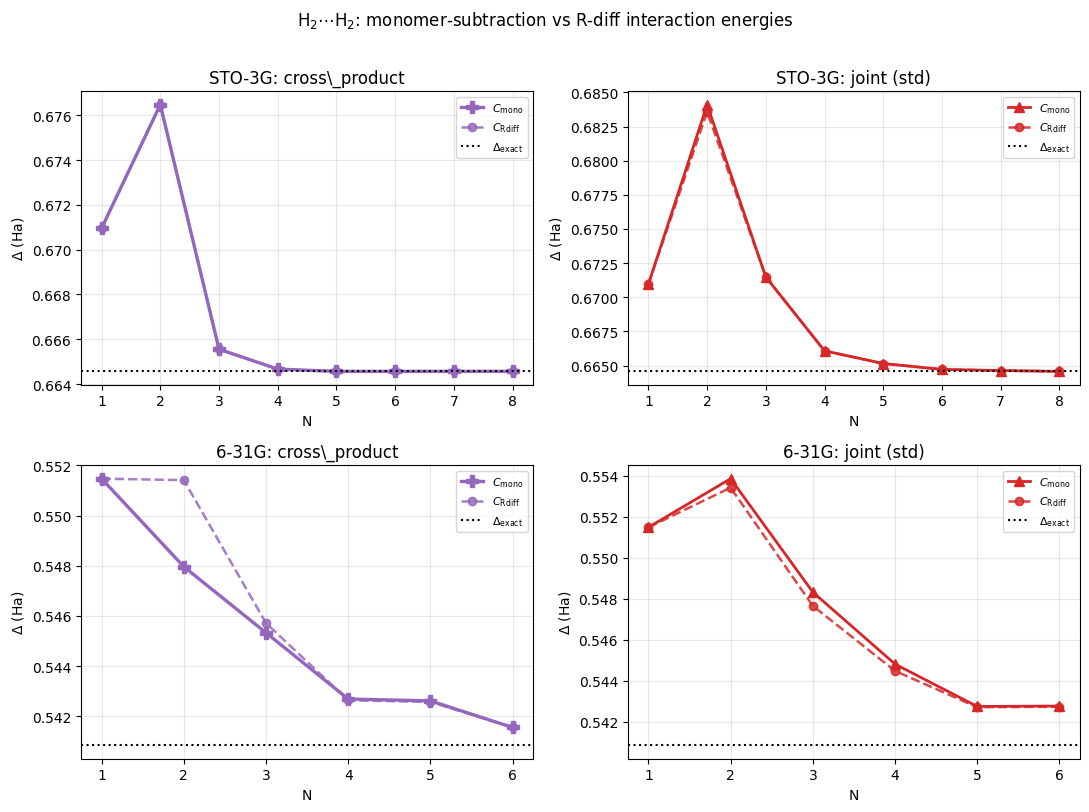

Saved: /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_cross_product/interaction_comparison/h2h2_C_mono_vs_C_rdiff__spectral_norm.png


In [8]:
# Fig A — interaction energies vs N
n_basis = len(BASIS_LIST)
fig, axes = plt.subplots(n_basis, 2, figsize=(11, 4.0 * n_basis), squeeze=False)

for row, basis in enumerate(BASIS_LIST):
    label = BASIS_CONFIG[basis]['label']
    sub = df_compare[df_compare['basis'] == basis]
    d_ex = delta_exact[basis]

    for col, name in enumerate(VARIANTS):
        ax = axes[row, col]
        s = sub[sub['variant'] == name].sort_values('N')
        st = VARIANT_STYLE[name]
        ax.plot(s['N'], s['C_mono'], color=st['color'], marker=st['marker'],
                ls='-', lw=st['lw'], ms=st['ms'], label=r'$C_{\mathrm{mono}}$')
        ax.plot(s['N'], s['C_rdiff'], color=st['color'], marker='o',
                ls='--', lw=1.8, ms=6, alpha=0.85, label=r'$C_{\mathrm{Rdiff}}$')
        ax.axhline(d_ex, color='k', ls=':', label=r'$\Delta_{\mathrm{exact}}$')
        ax.set_xlabel('N')
        ax.set_ylabel(r'$\Delta$ (Ha)')
        title_name = r'cross\_product' if name == 'cross_product' else 'joint (std)'
        ax.set_title(rf'{label}: {title_name}')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_xticks(list(s['N']))

fig.suptitle(r'H$_2\cdots$H$_2$: monomer-subtraction vs R-diff interaction energies', y=1.01)
fig.tight_layout()
path_a = artifact_path('h2h2_C_mono_vs_C_rdiff.png')
fig.savefig(path_a, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', path_a)


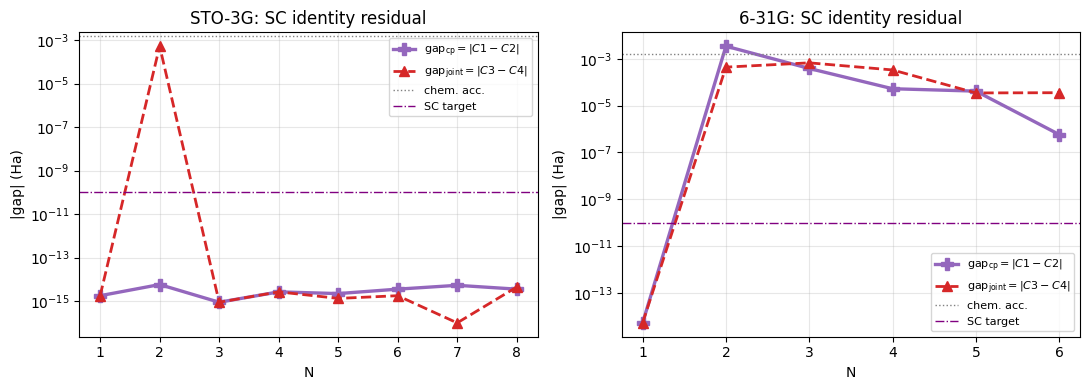

Saved: /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_cross_product/interaction_comparison/h2h2_sc_identity_gaps__spectral_norm.png


In [9]:
# Fig B — SC identity gaps
fig, axes = plt.subplots(1, n_basis, figsize=(5.5 * n_basis, 4.0), squeeze=False)
for col, basis in enumerate(BASIS_LIST):
    label = BASIS_CONFIG[basis]['label']
    ax = axes[0, col]
    g = df_gaps[df_gaps['basis'] == basis].sort_values('N')
    ax.semilogy(g['N'], np.maximum(g['gap_cp'], 1e-16),
                color=VARIANT_STYLE['cross_product']['color'],
                marker=VARIANT_STYLE['cross_product']['marker'],
                ls='-', lw=2.4, ms=9, label=r'gap$_{\mathrm{cp}}=|C1-C2|$')
    ax.semilogy(g['N'], np.maximum(g['gap_joint'], 1e-16),
                color=VARIANT_STYLE['joint']['color'],
                marker=VARIANT_STYLE['joint']['marker'],
                ls='--', lw=2.0, ms=7, label=r'gap$_{\mathrm{joint}}=|C3-C4|$')
    ax.axhline(CHEM_ACC, color='gray', ls=':', lw=1, label='chem. acc.')
    ax.axhline(SC_ASSERT, color='purple', ls='-.', lw=1, label='SC target')
    ax.set_xlabel('N')
    ax.set_ylabel('|gap| (Ha)')
    ax.set_title(rf'{label}: SC identity residual')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, which='both')
    ax.set_xticks(list(g['N']))

fig.tight_layout()
path_b = artifact_path('h2h2_sc_identity_gaps.png')
fig.savefig(path_b, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', path_b)


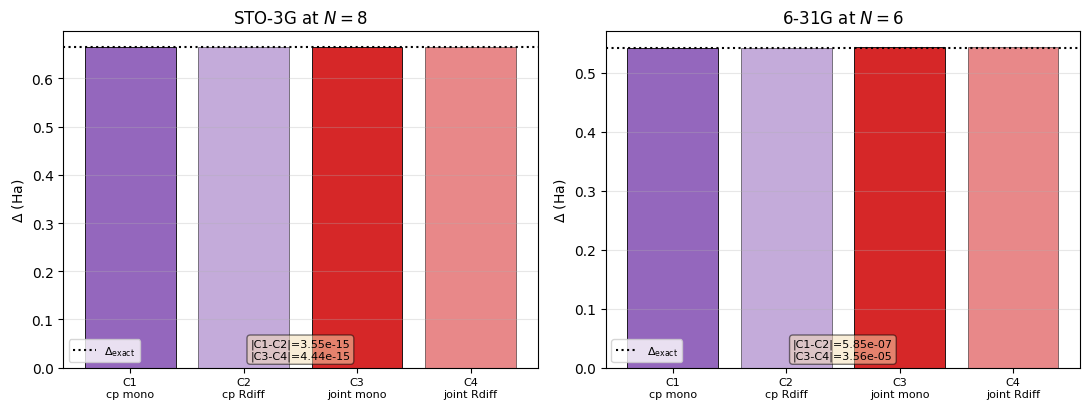

Saved: /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_cross_product/interaction_comparison/h2h2_C1C4_Nmax_bars__spectral_norm.png


In [10]:
# Fig C — bar chart of C1–C4 at N_max
fig, axes = plt.subplots(1, n_basis, figsize=(5.5 * n_basis, 4.2), squeeze=False)
bar_labels = ['C1\ncp mono', 'C2\ncp Rdiff', 'C3\njoint mono', 'C4\njoint Rdiff']
colors = [
    VARIANT_STYLE['cross_product']['color'],
    VARIANT_STYLE['cross_product']['color'],
    VARIANT_STYLE['joint']['color'],
    VARIANT_STYLE['joint']['color'],
]
alphas = [1.0, 0.55, 1.0, 0.55]

for col, basis in enumerate(BASIS_LIST):
    label = BASIS_CONFIG[basis]['label']
    ax = axes[0, col]
    sub = df_compare[df_compare['basis'] == basis]
    Nmax = int(sub['N'].max())
    r_cp = sub[(sub['N'] == Nmax) & (sub['variant'] == 'cross_product')].iloc[0]
    r_j = sub[(sub['N'] == Nmax) & (sub['variant'] == 'joint')].iloc[0]
    vals = [r_cp['C_mono'], r_cp['C_rdiff'], r_j['C_mono'], r_j['C_rdiff']]
    x = np.arange(4)
    bars = ax.bar(x, vals, color=colors, alpha=0.9, edgecolor='k', linewidth=0.6)
    for b, a in zip(bars, alphas):
        b.set_alpha(a)
    ax.axhline(delta_exact[basis], color='k', ls=':', label=r'$\Delta_{\mathrm{exact}}$')
    ax.set_xticks(x)
    ax.set_xticklabels(bar_labels, fontsize=8)
    ax.set_ylabel(r'$\Delta$ (Ha)')
    ax.set_title(rf'{label} at $N={Nmax}$')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')
    # annotate gaps
    ax.text(0.5, 0.02,
            f"|C1-C2|={r_cp['gap_identity']:.2e}\n|C3-C4|={r_j['gap_identity']:.2e}",
            transform=ax.transAxes, fontsize=8, va='bottom', ha='center',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.tight_layout()
path_c = artifact_path('h2h2_C1C4_Nmax_bars.png')
fig.savefig(path_c, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', path_c)


## 6. Interpretation

**Expected (and checked above):**

1. **`cross_product` restores size consistency.** C1 $\approx$ C2 (`gap_cp` at machine / SVD floor). The monomer-subtraction and R-diff definitions of the interaction energy therefore agree — the protocol fixes the size-consistency issue for interaction energies.

2. **`joint` (std) KQD is not size-consistent at fixed $N$.** C3 $\neq$ C4 in general (`gap_joint` larger than `gap_cp`, often $O(10^{-4})$–$O(10^{-3})$ Ha at low $N$). Monomer subtraction and the large-$R$ difference therefore disagree: the joint Krylov subspace does not factor into independent fragment Krylov spaces, matching the Kronecker §8b finding and the project's conclusion that quantum Krylov diagonalization is neither size-consistent nor extensive at fixed Krylov budget.

3. **Both methods can still approach $\Delta_{\mathrm{exact}}$** as $N$ grows (interaction *accuracy*), but only `cross_product` keeps the two *definitions* of interaction energy aligned at finite $N$.

Artifacts: `output/krylov_cross_product/interaction_comparison/*__spectral_norm.*`.


In [11]:
# Auto-summary narrative from the dataframe
print('=== Pass/fail narrative ===\n')
for basis in BASIS_LIST:
    label = BASIS_CONFIG[basis]['label']
    sub = df_compare[df_compare['basis'] == basis]
    Nmax = int(sub['N'].max())
    r_cp = sub[(sub['N'] == Nmax) & (sub['variant'] == 'cross_product')].iloc[0]
    r_j = sub[(sub['N'] == Nmax) & (sub['variant'] == 'joint')].iloc[0]
    # also report peak joint gap over N
    peak_j = float(sub[sub['variant'] == 'joint']['gap_identity'].max())
    peak_n = int(sub.loc[sub[sub['variant'] == 'joint']['gap_identity'].idxmax(), 'N'])

    cp_ok = r_cp['gap_identity'] < SC_ASSERT_RANK_DEF
    joint_fails = r_j['gap_identity'] > r_cp['gap_identity']

    print(f'{label} (N_max={Nmax}):')
    print(f'  cross_product: |C1-C2|={r_cp["gap_identity"]:.3e}  '
          f'{"PASS (SC identity)" if cp_ok else "CHECK (elevated gap)"}')
    print(f'  joint:         |C3-C4|={r_j["gap_identity"]:.3e}  '
          f'peak={peak_j:.3e} at N={peak_n}  '
          f'{"confirms non-SC (gap > cp)" if joint_fails else "unexpected: joint gap not larger"}')
    print(f'  Delta_exact={delta_exact[basis]:.6e}  '
          f'cp C_mono err={r_cp["err_vs_exact_mono"]:.3e}  '
          f'joint C_mono err={r_j["err_vs_exact_mono"]:.3e}')
    print()


=== Pass/fail narrative ===

STO-3G (N_max=8):
  cross_product: |C1-C2|=3.553e-15  PASS (SC identity)
  joint:         |C3-C4|=4.441e-15  peak=5.215e-04 at N=2  confirms non-SC (gap > cp)
  Delta_exact=6.645655e-01  cp C_mono err=4.441e-15  joint C_mono err=3.800e-06

6-31G (N_max=6):
  cross_product: |C1-C2|=5.849e-07  PASS (SC identity)
  joint:         |C3-C4|=3.562e-05  peak=6.712e-04 at N=3  confirms non-SC (gap > cp)
  Delta_exact=5.408354e-01  cp C_mono err=7.170e-04  joint C_mono err=1.921e-03

